# 15.2.2 自由滚动、数据划分与外推

## 学习目标与先修知识

按完整轨迹（trajectory）划分数据，比较一步损失、多步误差和新初值（initial condition）。

先修：15.2.1 离散映射；训练与独立评估。

## 具体问题

一个候选在训练观测（observation）上一步误差很小，却在新初值下逐渐偏离。评估时能否把每步真实状态（state）喂回去，再说它长期预测很好？

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import font_manager
from systems_science import plot_style
plot_style()
font_names={font.name for font in font_manager.fontManager.ttflist}
for name in ("Microsoft YaHei","SimHei","Noto Sans CJK SC"):
    if name in font_names:
        plt.rcParams["font.sans-serif"]=[name,"DejaVu Sans"]
        break
BLUE,PINK,GREEN="#008bfb","#ff0051","#00a56a"

## 初步实验

先作数值预测，再与完整模型（model）对照。

In [2]:
x=1.;preview=[x]
for _ in range(8):x=.88*x+.2*.3+.04*np.tanh(x);preview.append(x)
print("前三个状态：",preview[:3],"；终点：",preview[-1])

前三个状态： [1.0, np.float64(0.9704637662382305), np.float64(0.9439644348707712)] ；终点： 0.8326591790414524


## 模型假设

训练轨迹初值 0.2 U，留出轨迹初值 1.4 U；两者均由同一已知映射生成。候选参数（parameter）先固定，留出轨迹不参与参数选择。输入（input）在每个采样（sampling）间隔已知。 本章代码中的 x 仍是以 U 计的数值；tanh(x) 表示将物理量先除以 1 U，再经过无量纲（dimensionless）函数，乘上系数 q（U）。

## 数学解释与推导

一步均方误差为 $E_1=N^{-1}\sum(\hat F(x_n,u_n)-x_{n+1})^2$。自由预测满足 $\hat x_{n+1}=\hat F(\hat x_n,u_n)$，多步误差为 $E_H=H^{-1}\sum_{n=1}^{H}(\hat x_n-x_n)^2$。局部映射误差会通过之后的状态依赖累积。按点随机拆分同一轨迹会共享高度相关的时间邻域，因此此处按完整轨迹留出。多步训练可改变目标，但也不能再以同一留出轨迹当作独立验证。

## 核心实现

下面的函数保留计算步骤，可逐行修改并核对。

In [3]:
def discrete_step(x, u, a, b, q):
    """x and u are numerical values in U; tanh(x) means tanh(x_phys/(1 U))."""
    return float(a*x + b*u + q*math.tanh(x))


def teacher_forced(states, inputs, a, b, q):
    return [discrete_step(float(x), float(u), a, b, q)
            for x, u in zip(states[:-1], inputs)]


def discrete_roll(x0, inputs, a, b, q):
    states = [float(x0)]
    for u in inputs:
        states.append(discrete_step(states[-1], float(u), a, b, q))
    return states

## 对照实验

保持候选参数相同，比较留出轨迹的一步与滚动误差。再去掉 tanh 修正项，分别按一步损失和滚动损失选择系数 a。

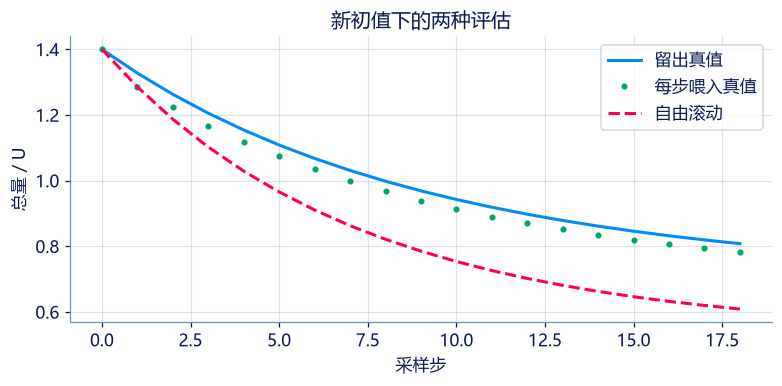

训练一步 MSE / 留出一步 MSE / 留出滚动 MSE： 0.00019390617547118357 0.0009799787834548755 0.028982412225169975
省略 tanh 修正时，一步/滚动训练选择的 a： 0.9169999999999999 0.9175
同一留出轨迹的自由滚动 MSE： [np.float64(0.00321505523934249), np.float64(0.00365016594152554)]


In [4]:
inputs=[.3]*18;train=np.asarray(discrete_roll(.2,inputs,.88,.2,.04));held=np.asarray(discrete_roll(1.4,inputs,.88,.2,.04));model=(.85,.2,.04)
train_one=np.asarray(teacher_forced(train,inputs,*model));held_one=np.asarray(teacher_forced(held,inputs,*model));held_roll=np.asarray(discrete_roll(1.4,inputs,*model))
fig,ax=plt.subplots(figsize=(7,3.4));ax.plot(held,label="留出真值",color=BLUE);ax.plot(np.r_[1.4,held_one],".",label="每步喂入真值",color=GREEN);ax.plot(held_roll,"--",label="自由滚动",color=PINK);ax.set(xlabel="采样步",ylabel="总量 / U",title="新初值下的两种评估");ax.legend();ax.grid(alpha=.25);plt.show()
print("训练一步 MSE / 留出一步 MSE / 留出滚动 MSE：",np.mean((train_one-train[1:])**2),np.mean((held_one-held[1:])**2),np.mean((held_roll[1:]-held[1:])**2))

# Under an intentionally misspecified family q=0, one-step and rollout
# objectives can select different a values on the same training trajectory.
grid=np.linspace(.82,.96,281)
one_scores=[];roll_scores=[]
for a in grid:
    one_scores.append(np.mean((np.asarray(teacher_forced(train,inputs,a,.2,0.))-train[1:])**2))
    roll_scores.append(np.mean((np.asarray(discrete_roll(.2,inputs,a,.2,0.))[1:]-train[1:])**2))
one_a=float(grid[np.argmin(one_scores)]);roll_a=float(grid[np.argmin(roll_scores)])
print("省略 tanh 修正时，一步/滚动训练选择的 a：",one_a,roll_a)
print("同一留出轨迹的自由滚动 MSE：",
      [np.mean((np.asarray(discrete_roll(1.4,inputs,a,.2,0.))[1:]-held[1:])**2)
       for a in [one_a,roll_a]])


## 结果解释

先固定候选参数，观察信息使用方式怎样改变预测。留出一步误差仍利用每步真实状态；长期部署时没有这些状态，必须看自由滚动和新条件。 同一错误函数族在两种训练目标下可能选出不同系数；在训练段选定系数后，用独立初值比较它们的滚动误差。

### 独立核对

对本节的核心结果使用解析值、代数恒等式或独立差分核对。

In [5]:
np.testing.assert_allclose(discrete_roll(1.4,inputs,.88,.2,.04),held)
assert abs(held_roll[-1]-held[-1])>0.01
assert len(held_one)==len(inputs)
print("留出真值由独立给定映射重算；末步偏差与序列长度核验通过。")
assert np.isfinite(one_a) and np.isfinite(roll_a)
assert min(one_scores)>=0 and min(roll_scores)>=0
assert abs(one_a-roll_a)>0.0001
print("两个目标使用相同训练轨迹；选参差异来自目标定义。")


留出真值由独立给定映射重算；末步偏差与序列长度核验通过。
两个目标使用相同训练轨迹；选参差异来自目标定义。


[在本章探索中改变条件](http://127.0.0.1:8000/chapters/15-02-%E7%A6%BB%E6%95%A3%E5%8A%A8%E5%8A%9B%E5%AD%A6%E5%AD%A6%E4%B9%A0/explore/)：先预测，再查看结果与简化假设。

## 练习与参考资料

先独立作答，再提交核对。

### 第 1 题 · 单项选择题：独立评估的划分

多条相关时间轨迹（trajectory）用于训练和最终评估，较稳妥的划分是什么？

- **A.** 同一轨迹随机挑相邻时间点分给两边。
- **B.** 用评估轨迹选参数（parameter）后仍叫独立评估。
- **C.** 按完整轨迹留出，参数选择不接触最终评估轨迹。
- **D.** 只留最后一个训练时间点。

[作答：独立评估的划分](http://127.0.0.1:8000/chapters/15-02-%E7%A6%BB%E6%95%A3%E5%8A%A8%E5%8A%9B%E5%AD%A6%E5%AD%A6%E4%B9%A0/practice/?question=p15-split-trajectories)

### 第 2 题 · 单项选择题：自由运行中的信息泄漏

候选每走一步就读取真实下一个状态（state）来修正输入（input），会怎样？

- **A.** 自动降低连续求解误差。
- **B.** 证明结构稳定。
- **C.** 这正是自由滚动的定义。
- **D.** 变成教师强制（teacher forcing）的一步预测（one-step-ahead prediction），不能代表自主长时预测。

[作答：自由运行中的信息泄漏](http://127.0.0.1:8000/chapters/15-02-%E7%A6%BB%E6%95%A3%E5%8A%A8%E5%8A%9B%E5%AD%A6%E5%AD%A6%E4%B9%A0/practice/?question=p15-rollout-leak)

### 第 3 题 · Python 计算题：自由运行的状态路径

只从初态出发，按输入（input）序列递推并包含初态返回。

**函数与代码模板**

```python
def solve(
    x0: float,
    inputs: list[float],
    a: float,
    b: float,
    q: float,
) -> list[float]:
    # 按题给公式完成计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `x0` | `float` | 初态。 | U |
| `inputs` | `list[float]` | 依次作用的输入。 | U |
| `a` | `float` | 状态（state）系数。 | 1 |
| `b` | `float` | 输入系数。 | 1 |
| `q` | `float` | 修正幅度。 | U |

**返回值**

直接返回 states（list[float]）。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `states` | `list[float]` | 初态及每步更新后的状态。 | U |

**计算规则**

从 x0 出发迭代上述映射；返回长度为 len(inputs)+1 的列表。

**约束与边界**

- 步数 0—100，全部有限。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| x0 | 初态。 | 1 | U |
| inputs | 依次作用的输入。 | [0.0, 0.0] | U |
| a | 状态（state）系数。 | 0.5 | 1 |
| b | 输入系数。 | 1 | 1 |
| q | 修正幅度。 | 0 | U |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
x0 = 1.0
inputs = [0.0, 0.0]
a = 0.5
b = 1.0
q = 0.0

result = solve(x0, inputs, a, b, q)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| states | 初态及每步更新后的状态。 | [1.0, 0.5, 0.25] | U |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = [1.0, 0.5, 0.25]
```

**样例解释**

首例无输入且 q=0，状态依次为1、0.5、0.25。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：自由运行的状态路径](http://127.0.0.1:8000/chapters/15-02-%E7%A6%BB%E6%95%A3%E5%8A%A8%E5%8A%9B%E5%AD%A6%E5%AD%A6%E4%B9%A0/practice/?question=p15-free-rollout)

### 第 4 题 · Python 计算题：多步误差与终点误差

真实与预测路径都包含相同初态；返回后续步的均方误差及终点绝对误差。

**函数与代码模板**

```python
def solve(
    truth: list[float],
    prediction: list[float],
) -> list[float]:
    # 按题给公式完成计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `truth` | `list[float]` | 真实状态（state）路径。 | U |
| `prediction` | `list[float]` | 预测路径。 | U |

**返回值**

直接返回 metrics（list[float]）。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `metrics` | `list[float]` | 依次为后续步 MSE 和终点绝对误差。 | U²、U |

**计算规则**

忽略相同初态；MSE = 后续各步差值平方的平均，终点绝对误差为末项差的绝对值。

**约束与边界**

- 两条路径等长，至少含一个后续状态，全部有限。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| truth | 真实状态（state）路径。 | [1.0, 0.8, 0.6] | U |
| prediction | 预测路径。 | [1.0, 0.9, 0.4] | U |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
truth = [1.0, 0.8, 0.6]
prediction = [1.0, 0.9, 0.4]

result = solve(truth, prediction)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| metrics | 依次为后续步 MSE 和终点绝对误差。 | [0.024999999999999988, 0.19999999999999996] | U²、U |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = [0.024999999999999988,
                   0.19999999999999996]
```

**样例解释**

首例后两步误差是0.1与-0.2；MSE=(0.01+0.04)/2。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：多步误差与终点误差](http://127.0.0.1:8000/chapters/15-02-%E7%A6%BB%E6%95%A3%E5%8A%A8%E5%8A%9B%E5%AD%A6%E5%AD%A6%E4%B9%A0/practice/?question=p15-rollout-error)

**进一步阅读**

[神经微分方程原论文](https://papers.nips.cc/paper_files/paper/2018/file/69386f6bb1dfed68692a24c8686939b9-Paper.pdf)的连续建模与本节固定间隔离散映射应区分。